In [1]:
import sys
sys.path.append("..")
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from typing import Dict, List, Tuple, Sequence
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from scipy.interpolate import interp1d
from tensorflow import keras
from keras.preprocessing.sequence import pad_sequences
from scipy.interpolate import PchipInterpolator
from keras.layers import Masking

2026-02-26 15:32:59.027463: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 15:32:59.067958: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 15:33:00.839695: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Data preprocessing

## Import data and join tables

### Functions

In [3]:
def import_data():
    conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
    experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
    experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
    logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
    properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
    response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
    responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
    source = pd.read_csv('../raw_data/Source.txt', sep='\t')

    return conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source

In [4]:
# This function is not needed since the column TObs is already present in the
# logcs dataframe. Anyway, this is part of the cleaning process, in the next
# part of the notebook
def remove_data_points(df, time_threshold=1000):
    # If we want to remove data points where the maximum time exceeds a certain
    # treshold
    max_time = df.groupby('ResponseID', as_index=False).max('Time')
    include = max_time.loc[max_time['Time'] <= time_threshold]['ResponseID'].tolist()
    filtered_df = df[df['ResponseID'].isin(include)]

    return filtered_df

In [5]:
def merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source):
    # Pivot ExperimentConditions table to have one row per ExperimentID before the merge
    # This table is not needed for the actual project, but will be useful for us
    # in the future...
    # experiment_conditions_pivot = experiment_conditions.pivot_table(index='ExperimentID', columns='ConditionID', values='Value').reset_index()

    # Merge the tables to create a single DataFrame for analysis. Will join data based on the logcs table
    data = responses.merge(experiments, left_on='ExperimentID', right_on='ID',
                           how='left'
                           ).drop(columns=['ID_y']
                                  ).rename(columns={'ID_x': 'ResponseID'})
    # data = data.merge(experiment_conditions_pivot, on='ExperimentID', how='left')
    # data = data.merge(response_properties, on='ResponseID', how='left'
    #                  ).rename(columns={'Value_x': 'ResponseValue',
    #                                    'Value_y': 'ResponsePropertiesValue'})
    data = data.merge(logcs, on='ResponseID', how='right')

    return data

### Explanations behind the functions...

In [7]:
# Import tables from the raw data directory
conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
source = pd.read_csv('../raw_data/Source.txt', sep='\t')

In [8]:
# Transform the LogCs table to have one row per ResponseID with a dictionay
logcs_dict = logcs.groupby('ResponseID').apply(
    lambda x: dict(zip(x['Time'], x['Value']))
).reset_index()

/tmp/ipykernel_195691/4111049196.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  logcs_dict = logcs.groupby('ResponseID').apply(


In [9]:
# Pivot ExperimentConditions table to have one row per ExperimentID before the merge
experiment_conditions_pivot = experiment_conditions.pivot_table(index='ExperimentID', columns='ConditionID', values='Value').reset_index()
experiment_conditions_pivot.fillna(0.101325, inplace=True)
experiment_conditions_pivot.fillna(0, inplace=True)

In [ ]:
# Merge the tables to create a single DataFrame for analysis
data = responses.merge(experiments, left_on='ExperimentID', right_on='ID', how='left').drop(columns=['ID_y']).rename(columns={'ID_x': 'ResponseID'})
#data = data.merge(experiment_conditions_pivot, on='ExperimentID', how='left')
# Do we really need to merge 'Source'?
#data = data.merge(source, left_on='SourceID', right_on='ID', how='left').drop(columns=['ID'])
data = data.merge(response_properties, on='ResponseID', how='left').rename(columns={'Value_x': 'ResponseValue', 'Value_y': 'ResponsePropertiesValue'})
# Table 'Conditions' has no added value so it has not been merged
# Wait for this one since I have to look for DART
# data = data.merge(logcs_dict, on='ResponseID', how='left')

In [11]:
data

,ResponseID,ExperimentID,Spec_rate,RateMethod,MethodID,OrganismID,OrganismSpecification,Comment,Logc0,LogcVar,...,MatrixID,In_on,Ph,Aw,Temperature,LinkId,UserId,PropertyID,Value,ComBaseID
0,1,6,-0.009999,NaN,plate_count,ec,"Serotype(s): O157:H7, Strain(s): 301C 204P 505...",NaN,NaN,0.3000,...,beef,ground beef salad with mayonnaise,6.07,NaN,5.0,O419_Ec,NaN,mixed_strains,NaN,O419_Ec
1,2,26,0.628000,NaN,plate_count,ec,"Serotype(s): O157:H7, Strain(s): 301C 204P 505...",NaN,NaN,4.5000,...,beef,ground roast beef slurry,6.00,NaN,21.0,M239_Ec,NaN,mixed_strains,NaN,M239_Ec
2,3,22,0.431700,NaN,plate_count,ec,"Serotype(s): O157:H7, Strain(s): 301C 204P 505...",NaN,NaN,3.9000,...,beef,ground roast beef slurry,5.40,NaN,21.0,M240_Ec,NaN,mixed_strains,NaN,M240_Ec
3,4,23,0.431700,NaN,plate_count,ec,"Serotype(s): O157:H7, Strain(s): 301C 204P 505...",NaN,NaN,3.4000,...,beef,ground roast beef slurry,5.40,NaN,21.0,M241_Ec,NaN,mixed_strains,NaN,M241_Ec
4,5,12,0.328900,NaN,plate_count,ec,"Serotype(s): O157:H7, Strain(s): 301C 204P 505...",NaN,NaN,2.4000,...,beef,ground roast beef slurry,5.00,NaN,21.0,M242_Ec,NaN,mixed_strains,NaN,M242_Ec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69897,60277,52397,NaN,NaN,od,ss,"Serotype(s): S.Tennessee, Strain(s): 67:z29:-",isolated from tahini,NaN,-0.3495,...,other/mix,buffered peptone water-tahini,NaN,NaN,37.5,BPWT-21-SA00318-0-R3,NaN,NaN,NaN,NaN
69898,60279,52399,NaN,NaN,od,ec,"Species: E. coli, Serotype(s): O108:H25, Strai...",isolated from sprouts,NaN,-0.3873,...,culture_medium,buffered peptone water,NaN,NaN,37.5,BPW-BfR-EC-17801-R2,NaN,NaN,NaN,NaN
69899,60280,52400,NaN,NaN,od,ec,"Species: E. coli, Serotype(s): O108:H25, Strai...",isolated from sprouts,NaN,-0.3873,...,culture_medium,buffered peptone water,NaN,NaN,37.5,BPW-BfR-EC-17801-R3,NaN,NaN,NaN,NaN
69900,60282,52402,NaN,NaN,od,ec,"Species: E. coli, Serotype(s): O108:H25, Strai...",isolated from sprouts,NaN,0.3562,...,other/mix,buffered peptone water-tahini,NaN,NaN,37.5,BPWT-BfR-EC-17801-R2,NaN,NaN,NaN,NaN


If we decide to remove some data...

In [19]:
# Determine the maximum time for each ResponseID
test = logcs.groupby('ResponseID')['Time'].max('Time')

In [20]:
# Determine the number of time points for each ResponseID
test1 = logcs.groupby('ResponseID')['Time'].count()

Text(0, 0.5, 'Frequency')

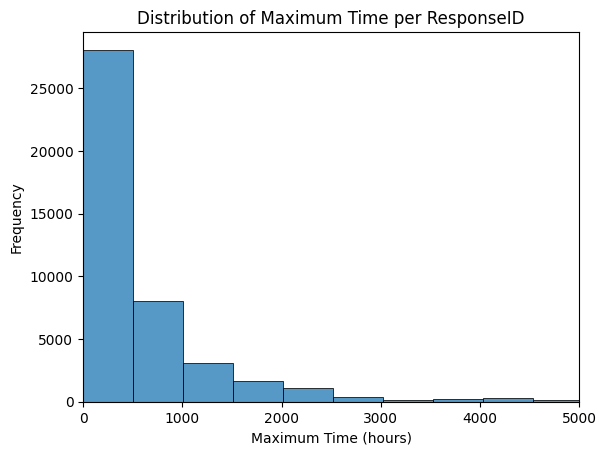

In [21]:
sns.histplot(test, binwidth=500)
plt.xlim(0, 5000)
plt.title('Distribution of Maximum Time per ResponseID')
plt.xlabel('Maximum Time (hours)')
plt.ylabel('Frequency')

From the graph above, the majority of the samples have a max time under 1000h. 
Only those samples will be used for the analysis. The rest will be considered 
outliers and removed from the dataset.

## Clean the dataset

### Functions

In [ ]:
# Has been incorporated in the clean_data function
def select_dataset(df, min_time_threshold=5, max_time_threshold=504):
    # Remove data points where the maximum time exceeds a certain treshold
    filtered_df = df[(df['TObs'] >= min_time_threshold) & (df['TObs'] <= max_time_threshold)]

    return filtered_df

In [6]:
def clean_data(df, min_time_threshold=10, max_time_threshold=504, min_temp_threshold=0, max_temp_threshold=30):
    # Keep ResponseIDs with at least 10 time points and a maximum time of 504 hours (21 days)
    response_counts = df.groupby('ResponseID').size()
    valid_response_ids = response_counts[response_counts >= 10].index
    df = df[df['ResponseID'].isin(valid_response_ids)]

    # Remove data points where the maximum time exceeds a certain treshold
    df = df[(df['TObs'] >= min_time_threshold) & (df['TObs'] <= max_time_threshold)]

    # Remove data points where the temperature is outside a certain treshold
    df = df[(df['Temperature'] >= min_temp_threshold) & (df['Temperature'] <= max_temp_threshold)]

    # Keep data from specific matrices only
    food_matrices = ['beef', 'poultry', 'seafood', 'pork']
    df = df[df['MatrixID'].isin(food_matrices)]

    # Keep data from specific organisms only
    organisms = ['ec', 'lm', 'ss']
    df = df[df['OrganismID'].isin(organisms)].reset_index()

    # Fill missing values in the DataFrame based on the provided fill_values
    # dictionary
    fill_values = {
        #'n2': 78.1,         # Must calculate the O2 and CO2 value too...
        'Temperature': 21,
        #'pH':,              # Use mean value from the in_on group
        #'Aw':,              # Use mean value from the in_on group
        #'pressure': 0.101325,
        #'acetic_acid':0,
        #'alta':0,
        #'apple_polyphenol':0,
        #'ascorbic_acid':0,
        #'benzoic_acid':0,
        #'betaine':0,
        #'calcium_propionate':0,
        #'carvacrol':0,
        #'chitosan':0,
        #'cinnamaldehyde':0,
        #'citric_acid':0,
        #'clo2':0,
        #'co2':0.04,         # Must calculate the O2 and N2 value too...
        #'dextrose':0,
        #'diacetic_acid':0,
        #'edta':0,
        #'erythorbate':0,
        #'ethanol':0,
        #'fat':,             # Use mean value from the in_on group or drop
        #'fructose':0,
        #'garlic':0,
        #'glucose':0,
        #'glycerol':0,
        #'green_tea_leaf':0,
        #'green_tea_polyphenol':0,
        #'hcl':0,
        #'irradiated':0,
        #'irradiation':0,
        #'kcl':0,
        #'lactic_acid':0,
        #'lauricidin':0,
        #'malic_acid':0,
        #'moisture':,        # Use mean value from the in_on group
        #'nacl':,            # Use mean value from the in_on group
        #'nitrate':0,
        #'nitrite':0,
        #'o2':21,              # Must calculate the N2 and CO2 value too...
        #'oregano':0,
        #'pomegranate':0,
        #'potassium_lactate':0,
        #'potassium_sorbate':0,
        #'propionic_acid':0,
        #'propylene_oxide':0,
        #'protein':,         # Use mean value from the in_on group or drop
        #'rosemary':0,
        #'sodium_lactate':0,
        #'sorbic_acid':0,
        #'sucrose':0,
        #'sugar':0,
        #'thymol':0
        'PropertyID': 'Other'
    }

    # Impute missing values for 'MethodID' with the most frequent value
    imputer = SimpleImputer(missing_values=np.nan,
                            strategy='most_frequent')
    imputer.fit(df[['MethodID']])
    df['MethodID'] = imputer.transform(df[['MethodID']]).ravel()

    # Drop columns that are not needed for the analysis.
    columns_to_drop = ['Spec_rate', 'RateMethod', 'Logc0', 'CombaseID_x',
                       'heated', 'OrganismSpecification', 'Comment', 'Ph', 'Aw',
                       'Value_x', 'ComBaseID', 'ComBaseID_y', 'UserId',
                       'Assumed', 'index', 'ExperimentID', 'LinkId', 'SourceID',
                       'MethodID', 'ID', 'TObs', 'LogcVar']

    for column, value in fill_values.items():
        if column in df.columns:
            df[column] = df[column].fillna(value)

    # Drop columns that are not needed for the analysis
    df = df.drop(columns=columns_to_drop, errors='ignore')

    return df

In [8]:
# Calculate co2, O2 and N2 values based on the pressure and the other gas values
def fill_gas_values(row):
    # for each empty co2 value, calculate the co2 value based on the pressure
    # and the other gas values. Do the same for o2 and n2. If all three are
    # empty, use the default values of 0.04 for co2, 21 for o2 and 78.1 for n2

    # Default values
    default_co2 = 0.04
    default_o2 = 21
    default_n2 = 78.1

    # Check if all gases are missing
    if pd.isna(row['co2']) and pd.isna(row['O2']) and pd.isna(row['N2']):
        row['co2'] = default_co2
        row['o2'] = default_o2
        row['n2'] = default_n2
    else:
        # Calculate co2, o2, n2 based on pressure or other values
        # In this case, we'll assume some linear relation for the sake of simplicity.

        # If co2 is missing, calculate based on pressure or other values
        if pd.isna(row['co2']):
            row['co2'] = (100 - row['n2'] - row['o2']) * default_co2

        # If o2 is missing, calculate based on pressure or other values
        if pd.isna(row['o2']):
            row['o2'] = (100 - row['n2'] - row['co2']) * default_o2

        # If n2 is missing, calculate based on pressure or other values
        if pd.isna(row['n2']):
            row['n2'] = (100 - row['o2'] - row['co2']) * default_n2

    return row

In [7]:
def split_dataset(df):
    # 1. Define the splitter (80% train, 20% test)
    gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

    # 2. Split based on Experiment_ID
    # This returns indices for the unique groups
    train_idx, test_idx = next(gss.split(df, groups=df['ResponseID']))

    # 3. Create the actual dataframes
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    return df_train, df_test

### Explanations

Import and merge the data...

In [25]:
data_merged['MatrixID'].value_counts()

NameError: name 'data_merged' is not defined

Since we want to predict food contamination, we should remove the data from
culture medium and keep only ['beef', 'poultry', 'produce', 'seafood', 'pork']. 
'other/mix' could be kept but it seems too undefined...

In [ ]:
# Remove data for everything but ['beef', 'poultry', 'produce', 'seafood', 'pork']
food_matrices = ['beef', 'poultry', 'produce', 'seafood', 'pork']
filtered_data = data_merged[data_merged['MatrixID'].isin(food_matrices)].reset_index()

In [ ]:
# Quantity of samples per matrix
filtered_data.groupby('MatrixID')['ResponseID'].nunique()

MatrixID
beef       1935
pork       1053
poultry    1997
produce    1424
seafood    1090
Name: ResponseID, dtype: int64

In [ ]:
# Quantity of samples per matrix
filtered_data.groupby('MatrixID')['ResponseID'].nunique()

MatrixID
beef       1935
pork       1053
poultry    1997
produce    1424
seafood    1090
Name: ResponseID, dtype: int64

In [ ]:
filtered_data

,index,ResponseID,ExperimentID,Spec_rate,RateMethod,MethodID,OrganismID,OrganismSpecification,Comment,Logc0,...,Temperature,LinkId,UserId,PropertyID,Value_x,ComBaseID_x,ID,Time,Value_y,ComBaseID_y
0,1616,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2525,0.0,3.39,ADRIAN_07
1,1617,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2526,24.0,4.99,ADRIAN_07
2,1618,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2527,31.0,4.33,ADRIAN_07
3,1619,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2528,48.0,4.77,ADRIAN_07
4,1620,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2529,55.0,5.71,ADRIAN_07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76828,273482,60254,52374.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_2,NaN,NaN,NaN,NaN,418125,7.0,5.16,Sn_Cu_38C_2
76829,273483,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_3,NaN,NaN,NaN,NaN,418126,1.0,1.25,Sn_Cu_38C_3
76830,273484,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_3,NaN,NaN,NaN,NaN,418127,3.0,3.09,Sn_Cu_38C_3
76831,273485,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_3,NaN,NaN,NaN,NaN,418128,5.0,4.67,Sn_Cu_38C_3


In [ ]:
filtered_data.shape

(76833, 28)

In [ ]:
# Determine the number of missing values in each column
filtered_data.isnull().sum().to_dict()

{'index': 0,
 'ResponseID': 0,
 'ExperimentID': 0,
 'Spec_rate': 60653,
 'RateMethod': 76833,
 'MethodID': 224,
 'OrganismID': 0,
 'OrganismSpecification': 21310,
 'Comment': 63028,
 'Logc0': 76833,
 'LogcVar': 0,
 'TObs': 0,
 'Assumed': 59399,
 'SourceID': 0,
 'MatrixID': 0,
 'In_on': 0,
 'Ph': 37355,
 'Aw': 49512,
 'Temperature': 0,
 'LinkId': 0,
 'UserId': 76833,
 'PropertyID': 22515,
 'Value_x': 74546,
 'ComBaseID_x': 22515,
 'ID': 0,
 'Time': 0,
 'Value_y': 0,
 'ComBaseID_y': 0}

In [ ]:
# Columns to drop
columns_to_drop = ['Spec_rate', 'RateMethod', 'Logc0', 'CombaseID_x', 'heated',
                   'OrganismSpecification', 'Comment', 'pH', 'Aw', 'Value_x',
                   'CombaseID_x', 'CombaseID_y']

In [ ]:
filtered_data['MethodID'].unique()

array(['plate_count', 'mpn', nan], dtype=object)

Default values for every conditions (replace NA by...). This includes the columns from 'Experiment Conditions' that I decided to remove for now

In [ ]:
fill_values = {
    #'n2': 78.1,         # Must calculate the O2 and CO2 value too...
    'Temperature': 22,
    #'pH':,              # Use mean value from the in_on group
    #'Aw':,              # Use mean value from the in_on group
    #'pressure': 0.101325,
    #'acetic_acid':0,
    #'alta':0,
    #'apple_polyphenol':0,
    #'ascorbic_acid':0,
    #'benzoic_acid':0,
    #'betaine':0,
    #'calcium_propionate':0,
    #'carvacrol':0,
    #'chitosan':0,
    #'cinnamaldehyde':0,
    #'citric_acid':0,
    #'clo2':0,
    #'co2':0.04,         # Must calculate the O2 and N2 value too...
    #'dextrose':0,
    #'diacetic_acid':0,
    #'edta':0,
    #'erythorbate':0,
    #'ethanol':0,
    #'fat':,             # Use mean value from the in_on group or drop
    #'fructose':0,
    #'garlic':0,
    #'glucose':0,
    #'glycerol':0,
    #'green_tea_leaf':0,
    #'green_tea_polyphenol':0,
    #'hcl':0,
    #'irradiated':0,
    #'irradiation':0,
    #'kcl':0,
    #'lactic_acid':0,
    #'lauricidin':0,
    #'malic_acid':0,
    #'moisture':,        # Use mean value from the in_on group
    #'nacl':,            # Use mean value from the in_on group
    #'nitrate':0,
    #'nitrite':0,
    #'o2':21,              # Must calculate the N2 and CO2 value too...
    #'oregano':0,
    #'pomegranate':0,
    #'potassium_lactate':0,
    #'potassium_sorbate':0,
    #'propionic_acid':0,
    #'propylene_oxide':0,
    #'protein':,         # Use mean value from the in_on group or drop
    #'rosemary':0,
    #'sodium_lactate':0,
    #'sorbic_acid':0,
    #'sucrose':0,
    #'sugar':0,
    #'thymol':0
    'PropertyID': 'Other'
}

In [8]:
conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source = import_data()

In [9]:
data_merged = merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source)

In [10]:
data_merged

,ResponseID,ExperimentID,Spec_rate,RateMethod,MethodID,OrganismID,OrganismSpecification,Comment,Logc0,LogcVar,...,Temperature,LinkId,UserId,PropertyID,Value_x,ComBaseID_x,ID,Time,Value_y,ComBaseID_y
0,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,1,0.00,4.02,A_1
1,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,2,22.50,3.99,A_1
2,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,3,97.75,3.94,A_1
3,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,4,117.50,3.92,A_1
4,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,5,144.25,3.78,A_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484891,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419495,6.50,5.43,Lm_paneer_40C_T2
484892,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419496,17.00,6.70,Lm_paneer_40C_T2
484893,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419497,21.00,7.51,Lm_paneer_40C_T2
484894,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419498,24.00,7.79,Lm_paneer_40C_T2


In [11]:
cleaned_data = clean_data(data_merged,
                          min_time_threshold=5,
                          max_time_threshold=504,
                          min_temp_threshold=0,
                          max_temp_threshold=30)

In [12]:
cleaned_data

,ResponseID,OrganismID,LogcVar,TObs,MatrixID,In_on,Temperature,PropertyID,ID,Time,Value_y
0,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2525,0.0,3.39
1,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2526,24.0,4.99
2,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2527,31.0,4.33
3,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2528,48.0,4.77
4,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2529,55.0,5.71
...,...,...,...,...,...,...,...,...,...,...,...
53247,60240,ss,2.73,7.0,poultry,cucumber,30.0,Other,418101,7.0,3.81
53248,60241,ss,3.13,7.0,poultry,cucumber,30.0,Other,418102,1.0,1.09
53249,60241,ss,3.13,7.0,poultry,cucumber,30.0,Other,418103,3.0,1.82
53250,60241,ss,3.13,7.0,poultry,cucumber,30.0,Other,418104,5.0,2.75


In [31]:
cleaned_data.shape

(53252, 12)

In [16]:
cleaned_data.groupby('MatrixID')[['Time', 'Temperature']].describe()

Time                                                           \
            count        mean         std  min   25%   50%     75%     max   
MatrixID                                                                     
beef      11931.0   73.282537  101.361532  0.0   5.0  24.0  101.00   504.0   
pork       6250.0  127.774439  119.334509  0.0  24.0  96.0  192.00  1200.0   
poultry   12744.0   70.119772   99.115343  0.0   4.1  22.0   96.00   504.0   
produce   10424.0   93.381910  104.237104  0.0   8.0  62.5  144.00  1344.0   
seafood   11903.0  113.414530  112.311828  0.0  24.0  73.0  168.07   648.0   

         Temperature                                                   
               count       mean       std  min  25%   50%   75%   max  
MatrixID                                                               
beef         11931.0   8.897913  6.601078  0.0  5.0   5.0  11.0  30.0  
pork          6250.0   9.984976  6.880526  0.7  6.4   7.0  12.0  30.0  
poultry      12744.0  16.286307  8.726733  0.0  8.0  15.0  25.0  30.0  
produce      10424.0  14.536838  8.301574  1.0  8.0  10.0  25.0  30.0  
seafood      11903.0   8.967848  7.024496  0.0  4.0   8.0  15.0  30.0

The temperature range we are going to keep is between -22 and 30C

In [17]:
selected_data = cleaned_data[(cleaned_data['Temperature'] >= 0) & (cleaned_data['Temperature'] <= 30)]

In [34]:
selected_data.groupby('Temperature')[['Time']].describe()

Time                                                          
              count        mean         std  min    25%    50%    75%     max
Temperature                                                                  
0.0          2599.0  136.493267  119.952264  0.0   21.0  119.0  225.0  504.00
0.7            72.0  193.833333  116.209015  0.0  114.0  180.0  258.0  406.00
1.0           711.0  199.426160  118.331820  0.0   96.0  216.0  312.0  384.00
2.0           523.0  132.272562  116.750354  0.0   46.8   96.0  192.0  504.00
2.3            12.0  190.416667  133.628697  0.0   80.0  187.5  305.0  400.00
...             ...         ...         ...  ...    ...    ...    ...     ...
27.5           25.0   77.600000   72.472983  0.0    4.0   48.0  144.0  192.00
27.9           18.0   37.027778   31.940994  0.0   13.0   30.0   51.0   99.75
28.0         1044.0   13.373611   22.991245  0.0    2.3    6.0   12.0  266.50
29.4          120.0    9.850000    6.775698  0.0    4.0    8.5   16.0   21.00
30.0         1663.0   20.764191   36.168308  0.0    2.8    7.0   24.0  336.00

[84 rows x 8 columns]

Text(0, 0.5, 'Frequency')

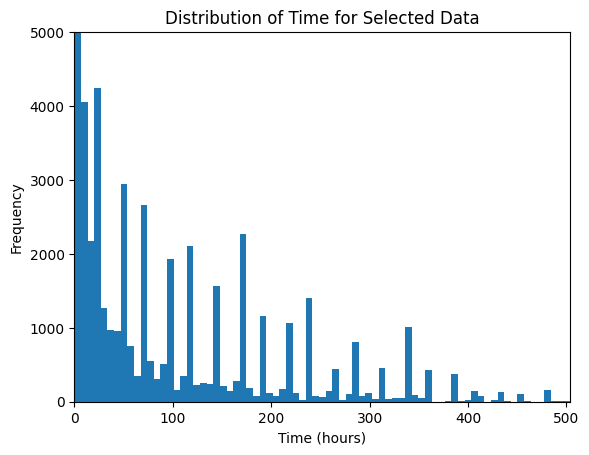

In [35]:
plt.hist(selected_data['Time'], bins=200)
plt.xlim(0, 504)
plt.ylim(0, 5000)
plt.title('Distribution of Time for Selected Data')
plt.xlabel('Time (hours)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

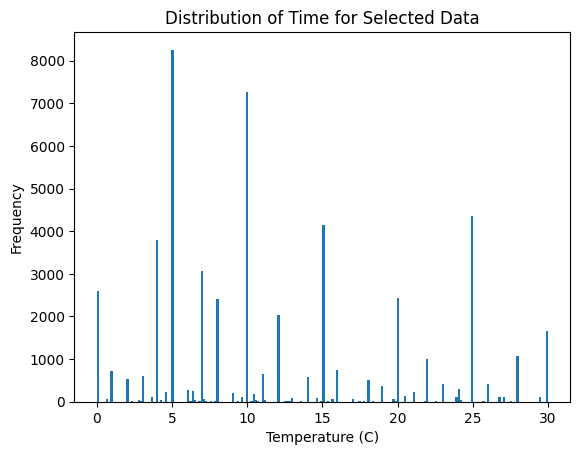

In [36]:
plt.hist(selected_data['Temperature'], bins=200)
plt.title('Distribution of Time for Selected Data')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')

In [37]:
cleaned_data.isna().sum()

ResponseID     0
MethodID       0
OrganismID     0
LogcVar        0
TObs           0
MatrixID       0
In_on          0
Temperature    0
PropertyID     0
ID             0
Time           0
Value_y        0
dtype: int64

# Data Engineering for lagtime and other variables

In [8]:
def data_engineering(df):
    # Calculate time delta for each ResponseID from the last time point
    df['Time_delta'] = df.groupby('ResponseID')['Time'].diff().fillna(0)

    # Calculate log delta for each ResponseID from the last time point
    df['log_delta'] = df.groupby('ResponseID')['Value'].diff().fillna(0)

    # Calculate time difference between T0 and TObs for each ResponseID
    df['Time_diff'] = df.groupby('ResponseID')['Time'].transform(lambda x: x - x.min()).round(0)

    # Calculate log difference between T0 and TObs for each ResponseID
    df['log_diff'] = df.groupby('ResponseID')['Value'].transform(lambda x: x - x.min())

    df.drop(columns=['In_on'],
            inplace=True)

    indices_to_drop = df[df['Time'] == 0].index
    df.drop(indices_to_drop, inplace=True)

    return df

In [9]:
def data_scale(df):
    # Select only numerical columns for scaling
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

    # Scale numerical features using MinMaxScaler
    scaler = MinMaxScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

    return df

In [10]:
def data_preproc(df,train_df):

    # Select only numerical columns for scaling
    numerical_cols = df.drop(columns=['ResponseID', 'Time_diff']).select_dtypes(include=['float64', 'int64']).columns
    #numerical_cols = ['Time', 'Temperature']

    # Scale numerical features using MinMaxScaler
    scaler = MinMaxScaler()
    scaler.fit(train_df[numerical_cols])
    df[numerical_cols] = scaler.transform(df[numerical_cols])

    # One-hot encode categorical features
    categorical_cols = df.select_dtypes(include=['object']).columns
    #categorical_cols = ['MatrixID']
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe.fit(df[categorical_cols])
    df[ohe.get_feature_names_out()] = ohe.transform(df[categorical_cols])
    df = df.drop(columns=categorical_cols)

    # Combine scaled numerical features with one-hot encoded categorical features
    #df = pd.concat([df['ResponseID'], df[numerical_cols].reset_index(drop=True), encoded_cat_df.reset_index(drop=True)], axis=1)

    return df

In [11]:
def interpolate(df):
    master_time_grid = np.arange(0, 504, 1)

    processed_data = []

    for response_id, group in engineered_df.groupby('ResponseID'):
        # 1. Ensure data is sorted by time (Crucial for PCHIP)
        group = group.sort_values('Time_diff')

        # 2. Drop duplicates (PCHIP fails if two points have the same time)
        group = group.drop_duplicates(subset=['Time_diff'])

        # 3. Get raw values as NumPy arrays
        x_sparse = group['Time_diff'].values
        y_sparse = group['log_diff'].values

        # Safety Check: We need at least 2 points to interpolate
        if len(x_sparse) < 2:
            continue

        # 4. Create the Interpolator Object
        # PCHIP is "shape-preserving" and won't overshoot your growth data
        interp_func = PchipInterpolator(x_sparse, y_sparse)

        # 5. Define points to calculate (only up to the end of this specific experiment)
        max_time = x_sparse.max()
        valid_grid_points = master_time_grid[master_time_grid <= max_time]

        # 6. Generate the new values
        y_interp = interp_func(valid_grid_points)

        # Rebuild the dataframe for this sequence
        temp_df = pd.DataFrame({
            'ResponseID': response_id,
            'Time_diff': valid_grid_points,
            'log_diff': y_interp,
            'Temperature': group['Temperature'].iloc[0], # Static feature
            'MatrixID': group['MatrixID'].iloc[0],  # Static feature
            'OrganismID': group['OrganismID'].iloc[0]   # Static feature
        })

        processed_data.append(temp_df)

    final_df = pd.concat(processed_data, ignore_index=True)

    return final_df

In [12]:
conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source = import_data()

In [13]:
data_merged = merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source)

In [14]:
cleaned_df = clean_data(data_merged,
                        min_time_threshold=5,
                        max_time_threshold=504,
                        min_temp_threshold=0,
                        max_temp_threshold=30)

In [15]:
cleaned_df

,ResponseID,OrganismID,MatrixID,In_on,Temperature,Time,Value
0,43334,lm,beef,ground beef,10.0,0.0,3.39
1,43334,lm,beef,ground beef,10.0,24.0,4.99
2,43334,lm,beef,ground beef,10.0,31.0,4.33
3,43334,lm,beef,ground beef,10.0,48.0,4.77
4,43334,lm,beef,ground beef,10.0,55.0,5.71
...,...,...,...,...,...,...,...
7371,59263,lm,pork,Cooked cured pork shoulder,16.0,240.0,7.05
7372,59263,lm,pork,Cooked cured pork shoulder,16.0,246.0,7.22
7373,59263,lm,pork,Cooked cured pork shoulder,16.0,252.0,7.26
7374,59263,lm,pork,Cooked cured pork shoulder,16.0,264.0,7.03


In [16]:
train_df, test_df = split_dataset(cleaned_df)

In [17]:
engineered_df = data_engineering(train_df)

/tmp/ipykernel_319983/507300970.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_delta'] = df.groupby('ResponseID')['Time'].diff().fillna(0)
/tmp/ipykernel_319983/507300970.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_delta'] = df.groupby('ResponseID')['Value'].diff().fillna(0)
/tmp/ipykernel_319983/507300970.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [18]:
engineered_df

,ResponseID,OrganismID,MatrixID,Temperature,Time,Value,Time_delta,log_delta,Time_diff,log_diff
1,43334,lm,beef,10.0,24.0,4.99,24.0,1.60,24.0,1.60
2,43334,lm,beef,10.0,31.0,4.33,7.0,-0.66,31.0,0.94
3,43334,lm,beef,10.0,48.0,4.77,17.0,0.44,48.0,1.38
4,43334,lm,beef,10.0,55.0,5.71,7.0,0.94,55.0,2.32
5,43334,lm,beef,10.0,96.0,7.40,41.0,1.69,96.0,4.01
...,...,...,...,...,...,...,...,...,...,...
7371,59263,lm,pork,16.0,240.0,7.05,12.0,-0.05,240.0,5.55
7372,59263,lm,pork,16.0,246.0,7.22,6.0,0.17,246.0,5.72
7373,59263,lm,pork,16.0,252.0,7.26,6.0,0.04,252.0,5.76
7374,59263,lm,pork,16.0,264.0,7.03,12.0,-0.23,264.0,5.53


In [19]:
final_df = interpolate(engineered_df)

In [20]:
final_df

,ResponseID,Time_diff,log_diff,Temperature,MatrixID,OrganismID
0,123,0,-0.350000,3.0,beef,lm
1,123,1,-0.349774,3.0,beef,lm
2,123,2,-0.349101,3.0,beef,lm
3,123,3,-0.347992,3.0,beef,lm
4,123,4,-0.346455,3.0,beef,lm
...,...,...,...,...,...,...
62281,59263,266,5.524914,16.0,pork,lm
62282,59263,267,5.522896,16.0,pork,lm
62283,59263,268,5.521346,16.0,pork,lm
62284,59263,269,5.520351,16.0,pork,lm


In [21]:
preproc_df = data_preproc(final_df, final_df)

In [22]:
preproc_df

,ResponseID,Time_diff,log_diff,Temperature,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_seafood,OrganismID_ec,OrganismID_lm,OrganismID_ss
0,123,0,0.065943,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,123,1,0.065944,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,123,2,0.065948,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,123,3,0.065953,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,123,4,0.065960,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
62281,59263,266,0.094329,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0
62282,59263,267,0.094319,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0
62283,59263,268,0.094311,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0
62284,59263,269,0.094307,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Explanations

In [301]:
from scipy.interpolate import PchipInterpolator
master_time_grid = np.arange(0, 504, 1)

processed_data = []

for response_id, group in engineered_df.groupby('ResponseID'):
    # 1. Ensure data is sorted by time (Crucial for PCHIP)
    group = group.sort_values('Time_diff')

    # 2. Drop duplicates (PCHIP fails if two points have the same time)
    group = group.drop_duplicates(subset=['Time_diff'])

    # 3. Get raw values as NumPy arrays
    x_sparse = group['Time_diff'].values
    y_sparse = group['log_diff'].values

    # Safety Check: We need at least 2 points to interpolate
    if len(x_sparse) < 2:
        continue

    # 4. Create the Interpolator Object
    # PCHIP is "shape-preserving" and won't overshoot your growth data
    interp_func = PchipInterpolator(x_sparse, y_sparse)

    # 5. Define points to calculate (only up to the end of this specific experiment)
    max_time = x_sparse.max()
    valid_grid_points = master_time_grid[master_time_grid <= max_time]

    # 6. Generate the new values
    y_interp = interp_func(valid_grid_points)

    # Rebuild the dataframe for this sequence
    temp_df = pd.DataFrame({
        'ResponseID': response_id,
        'Time_diff': valid_grid_points,
        'log_diff': y_interp,
        'Temperature': group['Temperature'].iloc[0], # Static feature
        'MatrixID': group['MatrixID'].iloc[0],  # Static feature
        'OrganismID': group['OrganismID'].iloc[0]   # Static feature
    })

    processed_data.append(temp_df)

final_df = pd.concat(processed_data, ignore_index=True)


In [302]:
final_df

,ResponseID,Time_diff,log_diff,Temperature,MatrixID,OrganismID
0,122,0,0.024483,3.0,beef,lm
1,122,1,0.029003,3.0,beef,lm
2,122,2,0.033654,3.0,beef,lm
3,122,3,0.038431,3.0,beef,lm
4,122,4,0.043332,3.0,beef,lm
...,...,...,...,...,...,...
78133,59263,266,5.524914,16.0,pork,lm
78134,59263,267,5.522896,16.0,pork,lm
78135,59263,268,5.521346,16.0,pork,lm
78136,59263,269,5.520351,16.0,pork,lm


In [303]:
final_df.groupby(['ResponseID'])['log_diff'].count()

ResponseID
122      481
123      481
124      481
125      481
126      481
        ... 
57982     59
57983     52
57984     52
59262    271
59263    271
Name: log_diff, Length: 509, dtype: int64

In [304]:
final_df['log_diff'].min(), final_df['log_diff'].max()

(np.float64(-13.998267878580005), np.float64(192.97160974602505))

## Padding

### Functions

In [23]:
def pad_data(df):
    # We calculate max per group for Y
    y_values = df.groupby('ResponseID')['log_diff'].max().values.reshape(-1, 1)

    # 3. Building X Sequences
    X_list = []
    # It's vital to iterate through the groups in the same order as we did for Y
    for x_id in df['ResponseID'].unique():
        group = df[df['ResponseID'] == x_id]
        # Features: Time, Temp, and the encoded Food Matrix
        features = group[['Time_diff', 'Temperature', 'MatrixID_beef',
                        'MatrixID_pork', 'MatrixID_poultry', 'MatrixID_seafood',
                        'OrganismID_ec', 'OrganismID_lm', 'OrganismID_ss']].values
        X_list.append(features)

    # 4. Padding X
    X_padded = pad_sequences(X_list, padding='post', dtype='float32', value=1000)

    return X_padded, y_values

In [24]:
X_train, y_train = pad_data(preproc_df)

In [25]:
X_test, y_test = pad_data(data_preproc(interpolate(data_engineering(test_df)), final_df))

/tmp/ipykernel_319983/507300970.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_delta'] = df.groupby('ResponseID')['Time'].diff().fillna(0)
/tmp/ipykernel_319983/507300970.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_delta'] = df.groupby('ResponseID')['Value'].diff().fillna(0)
/tmp/ipykernel_319983/507300970.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

## Get back to this section later

In [ ]:
# get X_test, y_test

In [305]:
clean_df = data_preproc(final_df)

In [306]:
clean_df

,ResponseID,Time_diff,log_diff,Temperature,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_seafood,OrganismID_ec,OrganismID_lm,OrganismID_ss
0,122,0,0.067753,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,122,1,0.067774,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,122,2,0.067797,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,122,3,0.067820,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,122,4,0.067844,0.100000,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
78133,59263,266,0.094329,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0
78134,59263,267,0.094319,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0
78135,59263,268,0.094311,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0
78136,59263,269,0.094307,0.533333,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# For each sample, I need to create an X sequence with its corresponding y
# Loop through the sequences to get:
    # X = np.array([sequence_a, sequence_b, sequence_c]).astype(np.float32)
    # y = np.expand_dims(np.array([y_a, y_b, y_c]).astype(np.float32),axis=-1)

# Get one sequence at a time
sequence_value = 'ResponseID'
sequences = engineered_df[sequence_value].unique().tolist()
sequence_id = sequences[150]
sequence_df = engineered_df[engineered_df[sequence_value] == sequence_id].sort_values(by='Time_diff')

In [343]:
np.array(clean_df[clean_df[sequence_value] == sequence_id].sort_values(by='Time_diff').drop(columns=['ResponseID', 'log_diff']))

array([[  0.        ,   0.33333333,   0.        , ...,   0.        ,
          1.        ,   0.        ],
       [  1.        ,   0.33333333,   0.        , ...,   0.        ,
          1.        ,   0.        ],
       [  2.        ,   0.33333333,   0.        , ...,   0.        ,
          1.        ,   0.        ],
       ...,
       [238.        ,   0.33333333,   0.        , ...,   0.        ,
          1.        ,   0.        ],
       [239.        ,   0.33333333,   0.        , ...,   0.        ,
          1.        ,   0.        ],
       [240.        ,   0.33333333,   0.        , ...,   0.        ,
          1.        ,   0.        ]], shape=(241, 9))

In [344]:
# 1. Group by Sample_ID and extract feature columns
sequences = [group[['Time_diff', 'log_diff', 'Temperature', 'MatrixID_beef',
                    'MatrixID_pork', 'MatrixID_poultry', 'MatrixID_seafood',
                    'OrganismID_ec', 'OrganismID_lm', 'OrganismID_ss']].values
             for _, group in clean_df.groupby('ResponseID')]

# 2. Pad to the length of the longest growth curve
# This creates the [Samples, Time_Steps, Features] 3D array
X_padded = pad_sequences(sequences, padding='post', dtype='float32', value=1000)

In [346]:
# We calculate max per group for Y
y_values = clean_df.groupby('ResponseID')['log_diff'].max().values.reshape(-1, 1)

# 3. Building X Sequences
X_list = []
# It's vital to iterate through the groups in the same order as we did for Y
for x_id in clean_df['ResponseID'].unique():
    group = clean_df[clean_df['ResponseID'] == x_id]
    # Features: Time, Temp, and the encoded Food Matrix
    features = group[['Time_diff', 'Temperature', 'MatrixID_beef',
                    'MatrixID_pork', 'MatrixID_poultry', 'MatrixID_seafood',
                    'OrganismID_ec', 'OrganismID_lm', 'OrganismID_ss']].values
    X_list.append(features)

# 4. Padding X
X_padded = pad_sequences(X_list, padding='post', dtype='float32', value=1000)

print(f"X shape: {X_padded.shape}") # (Samples, Max_Time_Steps, 3)
print(f"Y shape: {y_values.shape}")  # (Samples, 1)

X shape: (509, 504, 9)
Y shape: (509, 1)


### Train_test_split

In [351]:
# 1. Define the splitter (80% train, 20% test)
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

# 2. Split based on Experiment_ID
# This returns indices for the unique groups
train_idx, test_idx = next(gss.split(clean_df, groups=clean_df['ResponseID']))

# 3. Create the actual dataframes
df_train = clean_df.iloc[train_idx]
df_test = clean_df.iloc[test_idx]

In [331]:
y

array([[   1,    1,    1, ..., 1000, 1000, 1000],
       [   1,    1,    1, ..., 1000, 1000, 1000],
       [   1,    1,    1, ..., 1000, 1000, 1000],
       ...,
       [   0,    0,    0, ..., 1000, 1000, 1000],
       [   0,    0,    0, ..., 1000, 1000, 1000],
       [   0,    0,    0, ..., 1000, 1000, 1000]], shape=(509, 503))

In [311]:
# 1. Initial split: 80% for development (Train+Val), 20% for Final Test
X_dev, X_test, y_dev, y_test = train_test_split(
    rnn_input, y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# 2. Second split: From the 80%, take 15% (of total) for Validation
# 0.1875 * 0.8 = 0.15 of the original 100%
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.1875,
    random_state=42,
    shuffle=True
)

print(f"Train Shape: {X_train.shape}")      # ~420 samples
print(f"Validation Shape: {X_val.shape}") # ~90 samples
print(f"Test Shape: {X_test.shape}")       # ~120 samples

Train Shape: (330, 504, 9)
Validation Shape: (77, 504, 9)
Test Shape: (102, 504, 9)


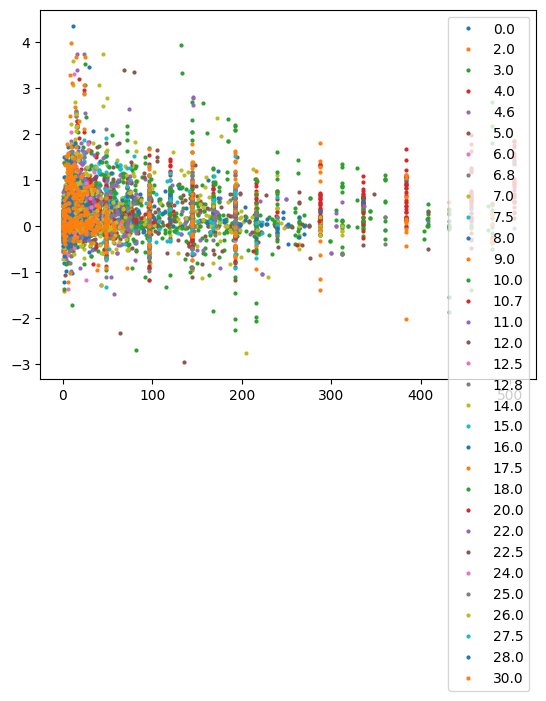

In [103]:
groups = engineered_df.groupby(['Temperature'])
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.Time_diff, group.log_delta, marker='o', linestyle='', ms=2, label=name)
ax.legend()

plt.show()

In [312]:
# Select only numerical columns for scaling
numerical_cols = df.select_dtypes(include=['float64']).columns
#num_transformer = make_pipeline(SimpleImputer(strategy='mean'), MinMaxScaler())
num_transformer = MinMaxScaler()

# One-hot encode categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
cat_transformer = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

preproc_basic = make_column_transformer([
    (num_transformer, numerical_cols),
    (cat_transformer, categorical_cols)],
    remainder='passthrough'
    )

In [313]:
preproc_basic

,transformers,"[('tuple', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'


## Get one sequence at a time

In [159]:
sequence_df

,ResponseID,OrganismID,MatrixID,Temperature,Time,Value,Time_delta,log_delta,Time_diff,log_diff,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_seafood
2140,17243,lm,seafood,0.333333,0.047430,0.534272,0.170819,0.467764,0.047619,0.045872,0.0,0.0,0.0,1.0
2141,17243,lm,seafood,0.333333,0.095059,0.600000,0.170819,0.502058,0.095238,0.117227,0.0,0.0,0.0,1.0
2142,17243,lm,seafood,0.333333,0.142687,0.635681,0.170819,0.458162,0.142857,0.155963,0.0,0.0,0.0,1.0
2143,17243,lm,seafood,0.333333,0.190316,0.647887,0.170819,0.423868,0.190476,0.169215,0.0,0.0,0.0,1.0
2144,17243,lm,seafood,0.333333,0.237944,0.616901,0.170819,0.360768,0.238095,0.135576,0.0,0.0,0.0,1.0
2145,17243,lm,seafood,0.333333,0.333201,0.736150,0.341637,0.580247,0.333333,0.265036,0.0,0.0,0.0,1.0
2146,17243,lm,seafood,0.333333,0.380830,0.773709,0.170819,0.460905,0.380952,0.305810,0.0,0.0,0.0,1.0
2147,17243,lm,seafood,0.333333,0.428458,0.719249,0.170819,0.326475,0.428571,0.246687,0.0,0.0,0.0,1.0
2148,17243,lm,seafood,0.333333,0.476087,0.738028,0.170819,0.433471,0.476190,0.267074,0.0,0.0,0.0,1.0


In [169]:
df = data_preproc(engineered_df)

In [170]:
df

,ResponseID,Temperature,Time,Value,Time_delta,log_delta,Time_diff,log_diff,OrganismID_ec,OrganismID_lm,OrganismID_ss,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_seafood
1,43334,0.333333,0.047430,0.469484,0.170819,0.625514,0.047619,0.163099,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,43334,0.333333,0.061322,0.407512,0.049822,0.315501,0.061508,0.095821,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,43334,0.333333,0.095059,0.448826,0.120996,0.466392,0.095238,0.140673,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,43334,0.333333,0.108950,0.537089,0.049822,0.534979,0.109127,0.236493,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5,43334,0.333333,0.190316,0.695775,0.291815,0.637860,0.190476,0.408767,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7371,59263,0.533333,0.476087,0.662911,0.085409,0.399177,0.476190,0.565749,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7372,59263,0.533333,0.487994,0.678873,0.042705,0.429355,0.488095,0.583078,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7373,59263,0.533333,0.499901,0.682629,0.042705,0.411523,0.500000,0.587156,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7374,59263,0.533333,0.523715,0.661033,0.085409,0.374486,0.523810,0.563710,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [179]:
df['Time_diff_round'] = df['Time_diff'].round(3)

In [201]:
times = df.groupby(['Time_diff_round'])[['log_diff']].count().sort_values(by='log_diff', ascending=False).head(44)

In [202]:
times = np.asarray(times.sort_index().index.to_list())

In [205]:
times

array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.018,
       0.019, 0.02 , 0.021, 0.024, 0.03 , 0.032, 0.034, 0.036, 0.042,
       0.044, 0.048, 0.06 , 0.062, 0.071, 0.095, 0.143, 0.19 , 0.238,
       0.286, 0.333, 0.381, 0.429, 0.476, 0.571, 0.667, 0.762])

In [257]:
indices = np.array([0,43])
times = np.array(engineered_df.groupby(['Time_diff'])[['log_diff']].count().sort_values(by='log_diff', ascending=False).head(44).sort_index().index.to_list()).astype(int)

In [247]:
engineered_df.groupby(['Time_diff'])[['log_diff']].count().sort_values(by='log_diff', ascending=False).head(44).sort_index()

,log_diff
Time_diff,
0.0,316
1.0,232
2.0,337
3.0,272
4.0,292
5.0,117
6.0,223
7.0,182
8.0,205


In [258]:
times

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  20,  21,  22,  24,  26,  27,  28,
        29,  30,  31,  32,  36,  40,  48,  72,  96, 120, 144, 168, 192,
       216, 240, 288, 336, 384])

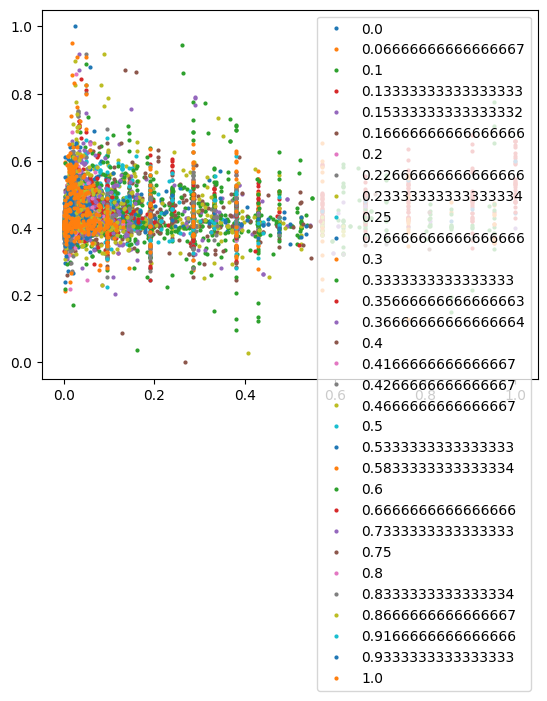

In [125]:
groups = df.groupby(['Temperature'])
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.Time_diff_round, group.log_delta, marker='o', linestyle='', ms=2, label=name)
ax.legend()

plt.show()

In [49]:
df.describe()

,ResponseID,Temperature,Time,Value,Time_delta,log_delta,Time_diff,log_diff,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_seafood
count,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000,6820.000000
mean,29241.331672,0.582422,0.132307,0.458558,0.081067,0.442367,0.130907,0.213491,0.126833,0.049853,0.736217,0.087097
std,8016.042812,0.259926,0.190348,0.235618,0.132493,0.072806,0.189324,0.223193,0.332810,0.217658,0.440715,0.281997
min,122.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28255.000000,0.333000,0.012000,0.300000,0.000000,0.405000,0.012000,0.033000,0.000000,0.000000,0.000000,0.000000
50%,28838.000000,0.583000,0.048000,0.466000,0.021000,0.427000,0.048000,0.131000,0.000000,0.000000,1.000000,0.000000
75%,29369.000000,0.833000,0.174000,0.620000,0.088000,0.472000,0.167250,0.333000,0.000000,0.000000,1.000000,0.000000
max,59263.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [36]:
scaler = MinMaxScaler()
df[['Time_delta', 'log_delta']] = scaler.fit_transform(df[['Time_delta', 'log_delta']])

In [ ]:
# TODO: prepare the static features for the model
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_matrix = encoder.fit_transform(cleaned_data[['MatrixID']])
encoded_matrix_df = pd.DataFrame(encoded_matrix, columns=encoder.get_feature_names_out(['MatrixID']))
cleaned_data = pd.concat([cleaned_data.reset_index(drop=True), encoded_matrix_df.reset_index(drop=True)], axis=1).drop(columns=['MatrixID'])

NameError: name 'cleaned_data' is not defined

In [27]:
df['ResponseID'].nunique()

509

/tmp/ipykernel_1904/479424839.py:5: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(group.Time_diff, group.log_delta, marker='o', linestyle='', ms=12, label=name)


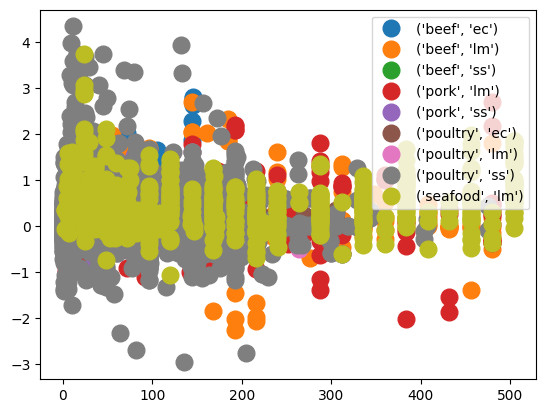

In [66]:
groups = engineered_df.groupby(['MatrixID', 'OrganismID'])
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.Time_diff, group.log_delta, marker='o', linestyle='', ms=12, label=name)
ax.legend()

plt.show()


In [50]:
df.groupby(['Time_diff'])[['log_diff']].count().sort_values(by='log_diff', ascending=False).head(40)

,log_diff
Time_diff,
0.095,242
0.002,209
0.006,206
0.000,194
0.190,183
0.286,178
0.007,167
0.018,164
0.381,163


In [265]:
df['ResponseID'].nunique()

509

### For JYL

In [ ]:
from ml_logic.baseline import ClassicalModel
baseline_params = ClassicalModel()

In [ ]:
baseline_params.fit(cleaned_data['Time'],cleaned_data['Value_y'], 'linear')

In [ ]:
baseline_params

In [ ]:
baseline_params.predict(cleaned_data['Time'])

0        4.562830
1        4.684726
2        4.720279
3        4.806621
4        4.842174
           ...   
52047    4.598383
52048    4.567909
52049    4.578067
52050    4.588225
52051    4.598383
Name: Time, Length: 52052, dtype: float64

We want to have a dataset that looks like :
X. shape = n_ResponseID (#sequences), 44 time points (24h + 20days) (#temporal dimensions), 1 features (log), shape = (n, 44, 1)

# RNN

In [ ]:
features_df = df.drop(columns=['ResponseID', 'OrganismID', 'PropertyID', 'LogcVar', 'TObs', 'MatrixID', 'In_on', 'Temperature', 'ID'])

In [ ]:
features_df

,Time,Value_y,Time_delta,log_delta
0,0.0,3.39,0.0,0.00
1,24.0,4.99,24.0,1.60
2,31.0,4.33,7.0,-0.66
3,48.0,4.77,17.0,0.44
4,55.0,5.71,7.0,0.94
5,96.0,7.40,41.0,1.69
6,144.0,9.44,48.0,2.04
7,151.0,9.43,7.0,-0.01
8,168.0,10.39,17.0,0.96
9,175.0,9.72,7.0,-0.67


## train_test_split

### split en time serie

In [219]:
# Let's define the global variables of our dataset
TARGET = 'Value'
N_TARGETS = 1
N_FEATURES = 4

In [220]:
# --------------------------------------------------- #
# Let's consider FOLDS with a length 7 datapoints     #
# (5 datapoints for train, 2 for test!)               #
# --------------------------------------------------- #

FOLD_LENGTH = 7

# --------------------------------------------------- #
# Let's consider FOLDS starting every 3 datapoints    #
# --------------------------------------------------- #

FOLD_STRIDE = 3

# --------------------------------------------------- #
# Let's consider a train-test-split ratio of 2/3      #
# --------------------------------------------------- #

TRAIN_TEST_RATIO = 0.66

In [221]:
from typing import Dict, List, Tuple, Sequence
from sklearn.model_selection import TimeSeriesSplit

def get_folds(
    df: pd.DataFrame,
    fold_length: int,
    fold_stride: int) -> List[pd.DataFrame]:
    """
    This function slides through the Time Series dataframe of shape (n_timesteps, n_features) to create folds
    - of equal `fold_length`
    - using `fold_stride` between each fold

    Args:
        df (pd.DataFrame): Overall dataframe
        fold_length (int): How long each fold should be in rows
        fold_stride (int): How many timesteps to move forward between taking each fold

    Returns:
        List[pd.DataFrame]: A list where each fold is a dataframe within
    """
    folds = []
    n_rows = df.shape[0]
    for start in range(0, n_rows - fold_length + 1, fold_stride):
        end = start + fold_length
        fold = df.iloc[start:end]
        folds.append(fold)
    return folds

In [222]:
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

print(f'The function generated {len(folds)} folds.')
print(f'Each fold has a shape equal to {folds[0].shape}.')

The function generated 2457 folds.
Each fold has a shape equal to (7, 12).


In [223]:
fold = folds[0]
fold

,ResponseID,Temperature,Time,Value,Time_delta,log_delta,Time_diff,log_diff,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_seafood
0,0.730661,0.333333,0.000000,0.319249,0.000000,0.406036,0.000000,0.000000,1.0,0.0,0.0,0.0
1,0.730661,0.333333,0.047619,0.469484,0.170819,0.625514,0.047619,0.163099,1.0,0.0,0.0,0.0
2,0.730661,0.333333,0.061508,0.407512,0.049822,0.315501,0.061508,0.095821,1.0,0.0,0.0,0.0
3,0.730661,0.333333,0.095238,0.448826,0.120996,0.466392,0.095238,0.140673,1.0,0.0,0.0,0.0
4,0.730661,0.333333,0.109127,0.537089,0.049822,0.534979,0.109127,0.236493,1.0,0.0,0.0,0.0
5,0.730661,0.333333,0.190476,0.695775,0.291815,0.637860,0.190476,0.408767,1.0,0.0,0.0,0.0
6,0.730661,0.333333,0.285714,0.887324,0.341637,0.685871,0.285714,0.616718,1.0,0.0,0.0,0.0


In [224]:
def train_test_split(fold:pd.DataFrame,
                     train_test_ratio: float,
                     input_length: int) -> Tuple[pd.DataFrame]:
    """From a fold dataframe, take a train dataframe and test dataframe based on
    the split ratio.
    - df_train should contain all the timesteps until round(train_test_ratio * len(fold))
    - df_test should contain all the timesteps needed to create all (X_test, y_test) tuples

    Args:
        fold (pd.DataFrame): A fold of timesteps
        train_test_ratio (float): The ratio between train and test 0-1
        input_length (int): How long each X_i will be

    Returns:
        Tuple[pd.DataFrame]: A tuple of two dataframes (fold_train, fold_test)
    """
    fold_train = fold.iloc[:round(train_test_ratio * len(fold))]
    fold_test = fold.iloc[round(train_test_ratio * len(fold)) - input_length:]
    return fold_train, fold_test

In [225]:
INPUT_LENGTH = 2

In [226]:
(fold_train, fold_test) = train_test_split(fold, TRAIN_TEST_RATIO, INPUT_LENGTH)

In [227]:
fold_test

,ResponseID,Temperature,Time,Value,Time_delta,log_delta,Time_diff,log_diff,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_seafood
3,0.730661,0.333333,0.095238,0.448826,0.120996,0.466392,0.095238,0.140673,1.0,0.0,0.0,0.0
4,0.730661,0.333333,0.109127,0.537089,0.049822,0.534979,0.109127,0.236493,1.0,0.0,0.0,0.0
5,0.730661,0.333333,0.190476,0.695775,0.291815,0.637860,0.190476,0.408767,1.0,0.0,0.0,0.0
6,0.730661,0.333333,0.285714,0.887324,0.341637,0.685871,0.285714,0.616718,1.0,0.0,0.0,0.0


In [228]:
def get_Xi_yi(
    fold:pd.DataFrame,
    input_length:int,
    output_length:int) -> Tuple[pd.DataFrame]:
    """given a fold, it returns one sequence (X_i, y_i) as based on the desired
    input_length and output_length with the starting point of the sequence being chosen at random based

    Args:
        fold (pd.DataFrame): A single fold
        input_length (int): How long each X_i should be
        output_length (int): How long each y_i should be

    Returns:
        Tuple[pd.DataFrame]: A tuple of two dataframes (X_i, y_i)
    """


 #   Xi_start = first_index
  #  Xi_last = first_index + input_length
   # yi_start = Xi_last + horizon - 1
    #yi_last = yi_start + output_length

    #Xi = fold[Xi_start:Xi_last]
    #yi = fold[yi_start:yi_last][TARGET]

    max_start_index = len(fold) - input_length - output_length
    start_index = np.random.randint(0, max_start_index + 1)
    end_index_X = start_index + input_length
    end_index_y = end_index_X + output_length
    X_i = fold[start_index:end_index_X]
    y_i = pd.DataFrame(fold[end_index_X:end_index_y][TARGET])
    return (X_i, y_i)


In [229]:
OUTPUT_LENGTH = 1

In [230]:
X_train_i, y_train_i = get_Xi_yi(fold_train, INPUT_LENGTH, OUTPUT_LENGTH)
X_test_i, y_test_i = get_Xi_yi(fold_test, INPUT_LENGTH, OUTPUT_LENGTH)

In [231]:
def get_X_y(
    fold:pd.DataFrame,
    number_of_sequences:int,
    input_length:int,
    output_length:int) -> Tuple[np.array]:
    """Given a fold generate X and y based on the number of desired sequences
    of the given input_length and output_length

    Args:
        fold (pd.DataFrame): Fold dataframe
        number_of_sequences (int): The number of X_i and y_i pairs to include
        input_length (int): Length of each X_i
        output_length (int): Length of each y_i

    Returns:
        Tuple[np.array]: A tuple of numpy arrays (X, y)
    """
    X = []
    y = []
    for _ in range(number_of_sequences):
        X_i, y_i = get_Xi_yi(fold, input_length, output_length)
        X.append(X_i.values)
        y.append(y_i.values)
    return np.array(X), np.array(y)

In [232]:
N_TRAIN = 3 # number_of_sequences_train
N_TEST =  2 # number_of_sequences_test

X_train, y_train = get_X_y(fold_train, N_TRAIN, INPUT_LENGTH, OUTPUT_LENGTH)
X_test, y_test = get_X_y(fold_test, N_TEST, INPUT_LENGTH, OUTPUT_LENGTH)

In [233]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3, 2, 12), (3, 1, 1), (2, 2, 12), (2, 1, 1))

# Model

In [26]:
from keras import models, layers, Input, optimizers, metrics, Sequential
from keras.regularizers import L1L2
from keras.layers import Dense, SimpleRNN, Flatten, Normalization

def initialize_model():
    model = Sequential()
    model.add(Input(shape=X_train.shape[1:])) # input shape is (input_length, n_features)
    model.add(layers.Masking(mask_value=1000))
    model.add(layers.LSTM(64,return_sequences=False))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='linear'))

    return model

In [27]:
model = initialize_model()
model.summary()

E0000 00:00:1772138044.170277  319983 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772138044.174791  319983 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 504, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# 2- Compilation
def compile_model(model):
    model.compile(loss='mae',
                optimizer='adam')
    return model

In [29]:
from keras.callbacks import EarlyStopping
es = EarlyStopping(patience=5, restore_best_weights=True)

model = compile_model(initialize_model())
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=2000,
    batch_size=16,
    callbacks=[es]
)

results_train = model.evaluate(X_train, y_train)
results_test = model.evaluate(X_test, y_test)
print(f"Train MAE: {results_train:.4f}")
print(f"Test MAE: {results_test:.4f}")

Epoch 1/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0820 - val_loss: 0.0586
Epoch 2/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0272 - val_loss: 0.0146
Epoch 3/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0211 - val_loss: 0.0073
Epoch 4/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0192 - val_loss: 0.0183
Epoch 5/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0170 - val_loss: 0.0096
Epoch 6/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0172 - val_loss: 0.0104
Epoch 7/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0183 - val_loss: 0.0157
Epoch 8/2000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0235 - val_loss: 0.0134
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0147
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 5.1362
Train MAE: 0.0147
Test MAE: 5.1362


In [ ]:
model.predict()